In [5]:
# 1. Pobranie danych

import yfinance as yf
import pandas as pd
from pathlib import Path

# =========================
# Parametry
# =========================
TICKER = "^GSPC"
START_DATE = "1900-01-01"
END_DATE = None
INTERVAL = "1d"

DATA_DIR = Path("data/market")
DATA_DIR.mkdir(parents=True, exist_ok=True)

BASE_NAME = f"{TICKER.replace('^','')}_{INTERVAL}"
PARQUET_PATH = DATA_DIR / f"{BASE_NAME}.parquet"
CSV_PATH = DATA_DIR / f"{BASE_NAME}.csv"


def load_or_download_data(
    ticker: str,
    start: str,
    end: str | None,
    interval: str,
    parquet_path: Path,
    csv_path: Path
) -> pd.DataFrame:
    """
    Ładuje dane z dysku jeśli istnieją,
    w przeciwnym razie pobiera je z yfinance i zapisuje.

    Parquet: format roboczy dla projektu
    CSV:     format pomocniczy do wglądu
    """

    if parquet_path.exists():
        print(f"[INFO] Wczytywanie danych z cache: {parquet_path}")
        try:
            df = pd.read_parquet(parquet_path)

            # CSV tylko do wglądu — jeśli nie istnieje, spróbuj go odtworzyć
            if not csv_path.exists():
                try:
                    df.to_csv(csv_path, index=True)
                    print(f"[INFO] (Podgląd) Dane zapisane do CSV: {csv_path}")
                except Exception as e:
                    raise RuntimeError(
                        f"Nie udało się zapisać CSV do {csv_path}"
                    ) from e

            return df
        except Exception as e:
            raise RuntimeError(
                f"Błąd podczas wczytywania danych z {parquet_path}"
            ) from e

    print("[INFO] Brak danych w cache — pobieranie z yfinance...")
    try:
        df = yf.download(
            tickers=ticker,
            start=start,
            end=end,
            interval=interval,
            auto_adjust=False,
            progress=False
        )
    except Exception as e:
        raise RuntimeError("Błąd podczas pobierania danych z yfinance") from e

    if df.empty:
        raise ValueError("Pobrane dane są puste — sprawdź ticker lub zakres dat")

    # Spłaszczenie MultiIndex
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [c[0] for c in df.columns]

    # Standaryzacja nazw kolumn
    df = df.rename(columns={
        "Open": "open",
        "High": "high",
        "Low": "low",
        "Close": "close",
        "Adj Close": "adj_close",
        "Volume": "volume"
    })

    df = df.dropna()

    try:
        df.to_parquet(parquet_path)
        print(f"[INFO] Dane zapisane do: {parquet_path}")
    except Exception as e:
        raise RuntimeError(
            f"Nie udało się zapisać danych do {parquet_path}"
        ) from e

    try:
        df.to_csv(csv_path, index=True)
        print(f"[INFO] (Podgląd) Dane zapisane do CSV: {csv_path}")
    except Exception as e:
        raise RuntimeError(
            f"Nie udało się zapisać CSV do {csv_path}"
        ) from e

    return df


# =========================
# Użycie
# =========================
df = load_or_download_data(
    ticker=TICKER,
    start=START_DATE,
    end=END_DATE,
    interval=INTERVAL,
    parquet_path=PARQUET_PATH,
    csv_path=CSV_PATH
)

print(df.head())
print(df.tail())
print(df.info())


[INFO] Brak danych w cache — pobieranie z yfinance...
[INFO] Dane zapisane do: data/market/GSPC_1d.parquet
[INFO] (Podgląd) Dane zapisane do CSV: data/market/GSPC_1d.csv
            adj_close      close       high        low       open  volume
Date                                                                     
1927-12-30  17.660000  17.660000  17.660000  17.660000  17.660000       0
1928-01-03  17.760000  17.760000  17.760000  17.760000  17.760000       0
1928-01-04  17.719999  17.719999  17.719999  17.719999  17.719999       0
1928-01-05  17.549999  17.549999  17.549999  17.549999  17.549999       0
1928-01-06  17.660000  17.660000  17.660000  17.660000  17.660000       0
              adj_close        close         high          low         open  \
Date                                                                          
2026-02-03  6917.810059  6917.810059  6993.080078  6862.049805  6985.450195   
2026-02-04  6882.720215  6882.720215  6936.089844  6838.799805  6924.500000

In [6]:
# Punkt 2: Walidacja surowych danych

from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Optional, Sequence
import pandas as pd


# =========================
# Wyjątki / wyniki walidacji
# =========================

class ValidationError(ValueError):
    """Błąd walidacji danych surowych."""


@dataclass(frozen=True)
class ValidationIssue:
    validator: str
    check: str
    message: str
    n_bad: int = 0
    csv_path: Optional[Path] = None


# =========================
# Baza dla walidatorów
# =========================

class BaseRawValidator:
    """Interfejs dla pojedynczego walidatora surowych danych."""
    name: str = "BaseRawValidator"

    def validate(
        self,
        df: pd.DataFrame,
        *,
        saveBlackSheeps: bool = False,
        blacksheep_dir: Optional[Path] = None,
    ) -> list[ValidationIssue]:
        raise NotImplementedError

    def _ensure_blacksheep_dir(self, blacksheep_dir: Optional[Path]) -> Path:
        if blacksheep_dir is None:
            raise ValidationError(
                "blacksheep_dir jest wymagany gdy saveBlackSheeps=True."
            )
        blacksheep_dir = Path(blacksheep_dir)
        blacksheep_dir.mkdir(parents=True, exist_ok=True)
        return blacksheep_dir

    def _save_blacksheeps(
        self,
        df_or_subset: pd.DataFrame,
        *,
        blacksheep_dir: Path,
        check: str,
    ) -> Path:
        # Uwaga: nie używam timestampów, żeby wyniki były deterministyczne przy powtarzalnych uruchomieniach.
        # Jeśli wolisz unikalne nazwy, łatwo dopisać suffix.
        safe_check = "".join(ch if ch.isalnum() or ch in ("-", "_") else "_" for ch in check)
        out_path = blacksheep_dir / f"{self.name}__{safe_check}.csv"
        df_or_subset.to_csv(out_path, index=True)
        return out_path


# =========================================
# Punkt 2: Walidacja surowych danych (cz. 1)
# 1) Indeks i oś czasu
# =========================================

class IndexAndTimeAxisValidator(BaseRawValidator):
    """
    Walidacje dla:
    1) Indeks i oś czasu

    Każdy podpunkt ma osobną metodę.
    """
    name = "IndexAndTimeAxisValidator"

    def validate(
        self,
        df: pd.DataFrame,
        *,
        saveBlackSheeps: bool = False,
        blacksheep_dir: Optional[Path] = None,
    ) -> list[ValidationIssue]:
        issues: list[ValidationIssue] = []

        # Kolejność ma znaczenie: najpierw typ indeksu, bo pozostałe checki na nim polegają. 
        issues += self.check_datetime_index(df, saveBlackSheeps=saveBlackSheeps, blacksheep_dir=blacksheep_dir)

        # Jeśli indeks nie jest DatetimeIndex, dalsze checki nie mają sensu.
        if issues and any(i.check == "check_datetime_index" for i in issues):
            raise ValidationError(self._format_issues(issues))

        issues += self.check_no_nat_in_index(df, saveBlackSheeps=saveBlackSheeps, blacksheep_dir=blacksheep_dir)
        issues += self.check_monotonic_increasing(df, saveBlackSheeps=saveBlackSheeps, blacksheep_dir=blacksheep_dir)
        issues += self.check_unique_index(df, saveBlackSheeps=saveBlackSheeps, blacksheep_dir=blacksheep_dir)
        issues += self.check_consistent_time_component_daily(df, saveBlackSheeps=saveBlackSheeps, blacksheep_dir=blacksheep_dir)
        issues += self.check_timezone_consistency(df, saveBlackSheeps=saveBlackSheeps, blacksheep_dir=blacksheep_dir)

        if issues:
            # W tym projekcie przyjmujemy twarde walidacje na raw.
            raise ValidationError(self._format_issues(issues))

        return issues

    # -------------------------
    # Podpunkt: DatetimeIndex - przetestowano
    # -------------------------

    def check_datetime_index(
        self,
        df: pd.DataFrame,
        *,
        saveBlackSheeps: bool,
        blacksheep_dir: Optional[Path],
    ) -> list[ValidationIssue]:
        if isinstance(df.index, pd.DatetimeIndex):
            return []

        csv_path: Optional[Path] = None
        if saveBlackSheeps:
            out_dir = self._ensure_blacksheep_dir(blacksheep_dir)
            # Nie da się jednoznacznie wskazać "złych rekordów" bez poprawnego indeksu czasu,
            # więc zapisujemy całe df jako blacksheeps.
            csv_path = self._save_blacksheeps(df, blacksheep_dir=out_dir, check="check_datetime_index")

        return [
            ValidationIssue(
                validator=self.name,
                check="check_datetime_index",
                message=f"Index musi być pandas.DatetimeIndex, a jest: {type(df.index).__name__}.",
                n_bad=len(df),
                csv_path=csv_path,
            )
        ]

    # -------------------------
    # Podpunkt: brak NaT w indeksie - przetestowano
    # -------------------------

    def check_no_nat_in_index(
        self,
        df: pd.DataFrame,
        *,
        saveBlackSheeps: bool,
        blacksheep_dir: Optional[Path],
    ) -> list[ValidationIssue]:
        idx: pd.DatetimeIndex = df.index  # po check_datetime_index
        nat_mask = idx.isna() # NaT → brakująca data / czas

        if not nat_mask.any():
            return []

        bad_df = df.loc[nat_mask]
        csv_path: Optional[Path] = None
        if saveBlackSheeps:
            out_dir = self._ensure_blacksheep_dir(blacksheep_dir)
            csv_path = self._save_blacksheeps(bad_df, blacksheep_dir=out_dir, check="check_no_nat_in_index")

        return [
            ValidationIssue(
                validator=self.name,
                check="check_no_nat_in_index",
                message="Index zawiera NaT (brakujące daty/czasy) – to błąd na surowych danych.",
                n_bad=int(nat_mask.sum()),
                csv_path=csv_path,
            )
        ]

    # -------------------------
    # Podpunkt: monotonicznie rosnący - do poprawy - nie zapisuje blacksheepów
    # -------------------------

    def check_monotonic_increasing(
        self,
        df: pd.DataFrame,
        *,
        saveBlackSheeps: bool,
        blacksheep_dir: Optional[Path],
    ) -> list[ValidationIssue]:
        idx: pd.DatetimeIndex = df.index
        if idx.is_monotonic_increasing:
            return []

        # Rekordy "odpowiedzialne" za fail: miejsca, gdzie kolejny timestamp jest mniejszy od poprzedniego.
        # Zaznaczamy oba wiersze: poprzedni i bieżący.
        diffs = idx[1:] < idx[:-1]
        bad_pos = diffs.to_numpy().nonzero()[0] + 1  # pozycje "bieżące"
        bad_pos = sorted(set(bad_pos.tolist() + (bad_pos - 1).tolist()))
        bad_df = df.iloc[bad_pos]

        csv_path: Optional[Path] = None
        if saveBlackSheeps:
            out_dir = self._ensure_blacksheep_dir(blacksheep_dir)
            csv_path = self._save_blacksheeps(bad_df, blacksheep_dir=out_dir, check="check_monotonic_increasing")

        return [
            ValidationIssue(
                validator=self.name,
                check="check_monotonic_increasing",
                message="Index nie jest monotonicznie rosnący (oś czasu jest 'poszarpana').",
                n_bad=len(bad_df),
                csv_path=csv_path,
            )
        ]

    # -------------------------
    # Podpunkt: unikalny indeks (brak duplikatów) - przetestowano
    # -------------------------

    def check_unique_index(
        self,
        df: pd.DataFrame,
        *,
        saveBlackSheeps: bool,
        blacksheep_dir: Optional[Path],
    ) -> list[ValidationIssue]:
        idx: pd.DatetimeIndex = df.index
        dup_mask = idx.duplicated(keep=False)

        if not dup_mask.any():
            return []

        bad_df = df.loc[dup_mask]
        csv_path: Optional[Path] = None
        if saveBlackSheeps:
            out_dir = self._ensure_blacksheep_dir(blacksheep_dir)
            csv_path = self._save_blacksheeps(bad_df, blacksheep_dir=out_dir, check="check_unique_index")

        # Dodatkowy kontekst: ile unikalnych duplikowanych timestampów
        n_dup_groups = idx[dup_mask].unique().shape[0]

        return [
            ValidationIssue(
                validator=self.name,
                check="check_unique_index",
                message=f"Index zawiera duplikaty timestampów (liczba grup duplikatów: {n_dup_groups}).",
                n_bad=int(dup_mask.sum()),
                csv_path=csv_path,
            )
        ]

    # -------------------------
    # Podpunkt: "dziwne godziny" dla danych dziennych
    # -------------------------

    def check_consistent_time_component_daily(
        self,
        df: pd.DataFrame,
        *,
        saveBlackSheeps: bool,
        blacksheep_dir: Optional[Path],
    ) -> list[ValidationIssue]:
        """
        Dla interwału 1d chcemy spójny komponent czasu w znacznikach (np. zawsze 00:00:00),
        bo mieszanie 00:00 i 16:00 potrafi psuć rolling/shift i joiny.

        Heurystyka:
        - bierzemy najczęstszy (mode) komponent czasu i wymagamy, by wszystkie były takie same.
        """
        idx: pd.DatetimeIndex = df.index

        # komponent czasu jako liczba ns od północy
        time_ns = (idx.hour.astype("int64") * 3600
                   + idx.minute.astype("int64") * 60
                   + idx.second.astype("int64")) * 1_000_000_000 + idx.nanosecond.astype("int64")

        # mode:
        vc = pd.Series(time_ns).value_counts(dropna=False)
        mode_time_ns = int(vc.index[0])
        bad_mask = time_ns != mode_time_ns

        if not bool(bad_mask.any()):
            return []

        bad_df = df.loc[bad_mask]

        csv_path: Optional[Path] = None
        if saveBlackSheeps:
            out_dir = self._ensure_blacksheep_dir(blacksheep_dir)
            csv_path = self._save_blacksheeps(bad_df, blacksheep_dir=out_dir, check="check_consistent_time_component_daily")

        # ładniejszy opis mode (HH:MM:SS)
        mode_sec = mode_time_ns // 1_000_000_000
        hh = mode_sec // 3600
        mm = (mode_sec % 3600) // 60
        ss = mode_sec % 60

        return [
            ValidationIssue(
                validator=self.name,
                check="check_consistent_time_component_daily",
                message=f"Niespójny komponent czasu w indeksie (dla 1d oczekuję stałej godziny; najczęstsza to {hh:02d}:{mm:02d}:{ss:02d}).",
                n_bad=int(bad_mask.sum()),
                csv_path=csv_path,
            )
        ]

    # -------------------------
    # Podpunkt: spójność TZ (albo brak TZ, albo konsekwentnie jedna) - nie przetestowano - "Teoretycznie nieosiągalne dla DatetimeIndex, ale zostawiam jako guard."
    # -------------------------

    def check_timezone_consistency(
        self,
        df: pd.DataFrame,
        *,
        saveBlackSheeps: bool,
        blacksheep_dir: Optional[Path],
    ) -> list[ValidationIssue]:
        idx: pd.DatetimeIndex = df.index

        # W pandas DatetimeIndex ma jedną tz albo None.
        # Ten check łapie przypadki pośrednie (np. index jako object -> już odpadliśmy),
        # oraz wymusza "albo brak TZ, albo jedna" (co i tak trzyma pandas).
        # Dodatkowo: jeżeli tz-aware, to zostawiamy (kontrakt mówi: albo brak TZ, albo konsekwentnie jedna).
        # Jeśli chcesz wymusić tz-naive, to tu zmienimy regułę.
        if idx.tz is None or idx.tz is not None:
            return []

        # Teoretycznie nieosiągalne dla DatetimeIndex, ale zostawiam jako guard.
        csv_path: Optional[Path] = None
        if saveBlackSheeps:
            out_dir = self._ensure_blacksheep_dir(blacksheep_dir)
            csv_path = self._save_blacksheeps(df, blacksheep_dir=out_dir, check="check_timezone_consistency")

        return [
            ValidationIssue(
                validator=self.name,
                check="check_timezone_consistency",
                message="Niespójna strefa czasowa w indeksie (wymagana jedna TZ albo brak TZ).",
                n_bad=len(df),
                csv_path=csv_path,
            )
        ]

    # -------------------------
    # Helper do formatowania
    # -------------------------

    def _format_issues(self, issues: Sequence[ValidationIssue]) -> str:
        lines = ["[RAW VALIDATION FAILED] 1) Indeks i oś czasu:"]
        for it in issues:
            extra = f" | blacksheeps: {it.csv_path}" if it.csv_path else ""
            lines.append(f"- {it.check}: {it.message} (n_bad={it.n_bad}){extra}")
        return "\n".join(lines)

# =========================================
# Punkt 2: Walidacja surowych danych (cz. 2)
# 2) Ciągłość dat (kalendarz sesji)
# =========================================

class SessionCalendarContinuityValidator(BaseRawValidator):
    """
    Walidacje dla:
    2) Ciągłość dat (kalendarz sesji)

    Kontrakt:
    - Poziom A (twardy): każda data w danych MUSI być dniem sesyjnym (NYSE dla ^GSPC).
      Jeśli nie -> ValidationError (+ opcjonalny zapis blacksheeps jako rekordy z błędnych dni).
    - Poziom B (miękki): brakujące sesje są dozwolone (nie imputujemy), ale logujemy WARNING
      (+ opcjonalny zapis listy brakujących sesji do CSV).
    """
    name = "SessionCalendarContinuityValidator"

    def __init__(self, calendar: str = "NYSE"):
        self.calendar = calendar

    def validate(
        self,
        df: pd.DataFrame,
        *,
        saveBlackSheeps: bool = False,
        blacksheep_dir: Optional[Path] = None,
    ) -> list[ValidationIssue]:
        issues: list[ValidationIssue] = []

        # Własny minimalny kontrakt wejścia (nie zależy od punktu 1 jako klasy)
        if not isinstance(df.index, pd.DatetimeIndex):
            raise ValidationError(
                f"{self.name} wymaga DatetimeIndex (otrzymano: {type(df.index).__name__})."
            )

        # A) Twardo: dni spoza kalendarza sesji
        issues += self.check_all_rows_are_session_days(
            df,
            saveBlackSheeps=saveBlackSheeps,
            blacksheep_dir=blacksheep_dir,
        )
        if issues and any(i.check == "check_all_rows_are_session_days" for i in issues):
            raise ValidationError(self._format_issues(issues))

        # B) Miękko: brakujące sesje (warning)
        issues += self.check_missing_sessions(
            df,
            saveBlackSheeps=saveBlackSheeps,
            blacksheep_dir=blacksheep_dir,
        )
        for w in [i for i in issues if i.check == "check_missing_sessions"]:
            extra = f" | blacksheeps: {w.csv_path}" if w.csv_path else ""
            print(f"[RAW VALIDATION WARNING] {self.name}.{w.check}: {w.message} (n_bad={w.n_bad}){extra}")

        return issues

    # -------------------------
    # Poziom A: daty w danych muszą być sesyjne - nie przetestowano
    # -------------------------

    def check_all_rows_are_session_days(
        self,
        df: pd.DataFrame,
        *,
        saveBlackSheeps: bool,
        blacksheep_dir: Optional[Path],
    ) -> list[ValidationIssue]:
        sessions = self._get_sessions_for_range(df)

        # Porównujemy po "dniu" (normalize), bo indeks może mieć godzinę.
        data_days = df.index.normalize().unique()
        session_days = sessions.normalize().unique()

        bad_days = data_days.difference(session_days)
        if len(bad_days) == 0:
            return []

        # rekordy odpowiedzialne za fail: wszystkie wiersze z bad_days
        bad_mask = df.index.normalize().isin(bad_days)
        bad_df = df.loc[bad_mask].copy()

        csv_path: Optional[Path] = None
        if saveBlackSheeps:
            out_dir = self._ensure_blacksheep_dir(blacksheep_dir)
            csv_path = self._save_blacksheeps(
                bad_df,
                blacksheep_dir=out_dir,
                check="check_all_rows_are_session_days",
            )

        sample = [d.strftime("%Y-%m-%d") for d in pd.to_datetime(bad_days[:5])]
        sample_txt = ", ".join(sample) + (" ..." if len(bad_days) > 5 else "")

        return [
            ValidationIssue(
                validator=self.name,
                check="check_all_rows_are_session_days",
                message=(
                    f"Znaleziono rekordy dla dni nienależących do kalendarza sesji ({self.calendar}). "
                    f"Przykłady dni: {sample_txt}."
                ),
                n_bad=int(bad_mask.sum()),
                csv_path=csv_path,
            )
        ]

    # -------------------------
    # Poziom B: brakujące sesje (warning) - nie przetestowano
    # -------------------------

    def check_missing_sessions(
        self,
        df: pd.DataFrame,
        *,
        saveBlackSheeps: bool,
        blacksheep_dir: Optional[Path],
    ) -> list[ValidationIssue]:
        sessions = self._get_sessions_for_range(df)

        data_days = df.index.normalize().unique()
        session_days = sessions.normalize().unique()

        missing_days = session_days.difference(data_days)
        if len(missing_days) == 0:
            return []

        # zapiszemy listę braków (to nie są "rekordy df", więc robimy osobny DF)
        missing_df = pd.DataFrame({"missing_session_day": pd.to_datetime(missing_days).sort_values()})

        csv_path: Optional[Path] = None
        if saveBlackSheeps:
            out_dir = self._ensure_blacksheep_dir(blacksheep_dir)
            # nadpisujemy _save_blacksheeps? nie, używamy go i zapisujemy z index=True (będzie 0..n-1)
            # bo BaseRawValidator i tak zapisuje index=True — to OK.
            csv_path = self._save_blacksheeps(
                missing_df,
                blacksheep_dir=out_dir,
                check="check_missing_sessions",
            )

        sample = [d.strftime("%Y-%m-%d") for d in pd.to_datetime(missing_days[:5])]
        sample_txt = ", ".join(sample) + (" ..." if len(missing_days) > 5 else "")

        return [
            ValidationIssue(
                validator=self.name,
                check="check_missing_sessions",
                message=(
                    f"W danych brakuje niektórych dni sesyjnych ({self.calendar}). "
                    f"Nie imputujemy (zgodnie z kontraktem). Przykłady braków: {sample_txt}."
                ),
                n_bad=len(missing_days),
                csv_path=csv_path,
            )
        ]

    # -------------------------
    # Backend kalendarza (exchange_calendars -> fallback pandas_market_calendars) - nie przetestowano
    # -------------------------

    def _get_sessions_for_range(self, df: pd.DataFrame) -> pd.DatetimeIndex:
        start = df.index.min().normalize()
        end = df.index.max().normalize()

        # 1) exchange_calendars
        try:
            import exchange_calendars as ecals  # type: ignore
            cal_code = "XNYS" if self.calendar.upper() == "NYSE" else self.calendar
            cal = ecals.get_calendar(cal_code)
            sessions = cal.sessions_in_range(start, end)
            if sessions.tz is not None:
                sessions = sessions.tz_convert(None)
            return pd.DatetimeIndex(sessions)
        except Exception:
            pass

        # 2) pandas_market_calendars
        try:
            import pandas_market_calendars as mcal  # type: ignore
            cal = mcal.get_calendar(self.calendar.upper())
            schedule = cal.schedule(start_date=start.date(), end_date=end.date())
            sessions = pd.DatetimeIndex(schedule.index)
            if sessions.tz is not None:
                sessions = sessions.tz_convert(None)
            return sessions
        except Exception as e:
            raise ValidationError(
                "Nie mogę załadować kalendarza sesji. "
                "Zainstaluj jedno z: exchange_calendars lub pandas_market_calendars.\n"
                f"Szczegóły: {repr(e)}"
            )

    def _format_issues(self, issues: Sequence[ValidationIssue]) -> str:
        lines = [f"[RAW VALIDATION FAILED] 2) Ciągłość dat (kalendarz sesji: {self.calendar}):"]
        for it in issues:
            extra = f" | blacksheeps: {it.csv_path}" if it.csv_path else ""
            lines.append(f"- {it.check}: {it.message} (n_bad={it.n_bad}){extra}")
        return "\n".join(lines)


# =========================================
# Punkt 2: Walidacja surowych danych (cz. 3)
# 3) Walidacja kolumn i typów
# =========================================

class ColumnsAndTypesValidator(BaseRawValidator):
    """
    Walidacje dla:
    3) Walidacja kolumn i typów

    Twarde zasady na RAW (fail fast):
    - Muszą istnieć kolumny: Open, High, Low, Close
    - Kolumny OHLC muszą być numeryczne i konwertowalne do float64
    - Brak NaN w OHLC

    Opcjonalnie (jeśli kolumny istnieją):
    - Adj Close i Volume nie są wymagane, ale jeśli są -> też walidujemy typ (i NaN dla Adj Close).
      (Volume: dopuszczamy NaN? na RAW zwykle nie; tu trzymam twardo: brak NaN jeśli istnieje.)
    """
    name = "ColumnsAndTypesValidator"

    def __init__(
        self,
        required_cols: Sequence[str] = ("close", "high", "low", "open", "volume"),
        optional_cols: Sequence[str] = (),
        enforce_no_nan_optional: bool = True,
    ):
        self.required_cols = list(required_cols)
        self.optional_cols = list(optional_cols)
        self.enforce_no_nan_optional = bool(enforce_no_nan_optional)

    def validate(
        self,
        df: pd.DataFrame,
        *,
        saveBlackSheeps: bool = False,
        blacksheep_dir: Optional[Path] = None,
    ) -> list[ValidationIssue]:
        issues: list[ValidationIssue] = []

        issues += self.check_required_columns_present(
            df, saveBlackSheeps=saveBlackSheeps, blacksheep_dir=blacksheep_dir
        )

        # Jeśli brakuje required columns, dalsze checki nie mają sensu.
        if issues and any(i.check == "check_required_columns_present" for i in issues):
            raise ValidationError(self._format_issues(issues))

        issues += self.check_required_columns_numeric_castable(
            df, saveBlackSheeps=saveBlackSheeps, blacksheep_dir=blacksheep_dir
        )
        issues += self.check_no_nan_in_required(
            df, saveBlackSheeps=saveBlackSheeps, blacksheep_dir=blacksheep_dir
        )

        # Optional columns: walidujemy tylko jeśli istnieją
        issues += self.check_optional_columns_types(
            df, saveBlackSheeps=saveBlackSheeps, blacksheep_dir=blacksheep_dir
        )
        if self.enforce_no_nan_optional:
            issues += self.check_no_nan_in_optional(
                df, saveBlackSheeps=saveBlackSheeps, blacksheep_dir=blacksheep_dir
            )

        if issues:
            raise ValidationError(self._format_issues(issues))

        return issues

    # -------------------------
    # Podpunkt: wymagane kolumny istnieją - przetestowano
    # -------------------------

    def check_required_columns_present(
        self,
        df: pd.DataFrame,
        *,
        saveBlackSheeps: bool,
        blacksheep_dir: Optional[Path],
    ) -> list[ValidationIssue]:
        missing = [c for c in self.required_cols if c not in df.columns]
        if not missing:
            return []

        csv_path: Optional[Path] = None
        if saveBlackSheeps:
            out_dir = self._ensure_blacksheep_dir(blacksheep_dir)
            # Brak kolumn -> nie ma "złych rekordów" per-row; zapisujemy snapshot całego df (nagłówki też)
            csv_path = self._save_blacksheeps(df, blacksheep_dir=out_dir, check="check_required_columns_present")

        return [
            ValidationIssue(
                validator=self.name,
                check="check_required_columns_present",
                message=f"Brakuje wymaganych kolumn: {missing}. Dostępne kolumny: {list(df.columns)}.",
                n_bad=len(missing),
                csv_path=csv_path,
            )
        ]

    # -------------------------
    # Podpunkt: wymagane kolumny numeryczne i castowalne do float64 - przetestowano
    # -------------------------

    def check_required_columns_numeric_castable(
        self,
        df: pd.DataFrame,
        *,
        saveBlackSheeps: bool,
        blacksheep_dir: Optional[Path],
    ) -> list[ValidationIssue]:
        bad_cols: list[str] = []
        for c in self.required_cols:
            # najpierw szybki typ-check
            if pd.api.types.is_numeric_dtype(df[c]):
                continue
            # próbujemy twardej konwersji
            try:
                pd.to_numeric(df[c], errors="raise")
            except Exception:
                bad_cols.append(c)

        if not bad_cols:
            return []

        csv_path: Optional[Path] = None
        if saveBlackSheeps:
            out_dir = self._ensure_blacksheep_dir(blacksheep_dir)
            # zapisujemy tylko problematyczne kolumny + index, żeby łatwiej debugować
            csv_path = self._save_blacksheeps(df[bad_cols].copy(), blacksheep_dir=out_dir, check="check_required_columns_numeric_castable")

        return [
            ValidationIssue(
                validator=self.name,
                check="check_required_columns_numeric_castable",
                message=(
                    "Niektóre wymagane kolumny nie są numeryczne i/lub nie dają się bezpiecznie "
                    f"zrzutować do typu liczbowego: {bad_cols}."
                ),
                n_bad=len(bad_cols),
                csv_path=csv_path,
            )
        ]

    # -------------------------
    # Podpunkt: brak NaN w wymaganych OHLC - przetestowano
    # -------------------------

    def check_no_nan_in_required(
        self,
        df: pd.DataFrame,
        *,
        saveBlackSheeps: bool,
        blacksheep_dir: Optional[Path],
    ) -> list[ValidationIssue]:
        sub = df[self.required_cols]
        nan_mask = sub.isna().any(axis=1)
        if not bool(nan_mask.any()):
            return []

        bad_df = df.loc[nan_mask, self.required_cols].copy()

        csv_path: Optional[Path] = None
        if saveBlackSheeps:
            out_dir = self._ensure_blacksheep_dir(blacksheep_dir)
            csv_path = self._save_blacksheeps(bad_df, blacksheep_dir=out_dir, check="check_no_nan_in_required")

        return [
            ValidationIssue(
                validator=self.name,
                check="check_no_nan_in_required",
                message="W wymaganych kolumnach OHLC wykryto NaN (to błąd na surowych danych).",
                n_bad=int(nan_mask.sum()),
                csv_path=csv_path,
            )
        ]

    # -------------------------
    # Podpunkt: optional columns (jeśli istnieją) — typy - nie przetestowano
    # -------------------------

    def check_optional_columns_types(
        self,
        df: pd.DataFrame,
        *,
        saveBlackSheeps: bool,
        blacksheep_dir: Optional[Path],
    ) -> list[ValidationIssue]:
        present_optional = [c for c in self.optional_cols if c in df.columns]
        if not present_optional:
            return []

        bad_cols: list[str] = []
        for c in present_optional:
            if pd.api.types.is_numeric_dtype(df[c]):
                continue
            try:
                pd.to_numeric(df[c], errors="raise")
            except Exception:
                bad_cols.append(c)

        if not bad_cols:
            return []

        csv_path: Optional[Path] = None
        if saveBlackSheeps:
            out_dir = self._ensure_blacksheep_dir(blacksheep_dir)
            csv_path = self._save_blacksheeps(df[bad_cols].copy(), blacksheep_dir=out_dir, check="check_optional_columns_types")

        return [
            ValidationIssue(
                validator=self.name,
                check="check_optional_columns_types",
                message=f"Opcjonalne kolumny istnieją, ale mają niepoprawny typ/format liczbowy: {bad_cols}.",
                n_bad=len(bad_cols),
                csv_path=csv_path,
            )
        ]

    # -------------------------
    # Podpunkt: optional columns (jeśli istnieją) — brak NaN - nie przetestowano
    # -------------------------

    def check_no_nan_in_optional(
        self,
        df: pd.DataFrame,
        *,
        saveBlackSheeps: bool,
        blacksheep_dir: Optional[Path],
    ) -> list[ValidationIssue]:
        present_optional = [c for c in self.optional_cols if c in df.columns]
        if not present_optional:
            return []

        sub = df[present_optional]
        nan_mask = sub.isna().any(axis=1)
        if not bool(nan_mask.any()):
            return []

        bad_df = df.loc[nan_mask, present_optional].copy()

        csv_path: Optional[Path] = None
        if saveBlackSheeps:
            out_dir = self._ensure_blacksheep_dir(blacksheep_dir)
            csv_path = self._save_blacksheeps(bad_df, blacksheep_dir=out_dir, check="check_no_nan_in_optional")

        return [
            ValidationIssue(
                validator=self.name,
                check="check_no_nan_in_optional",
                message=f"W opcjonalnych kolumnach {present_optional} wykryto NaN (ustawione jako błąd na RAW).",
                n_bad=int(nan_mask.sum()),
                csv_path=csv_path,
            )
        ]

    # -------------------------
    # Helper do formatowania
    # -------------------------

    def _format_issues(self, issues: Sequence[ValidationIssue]) -> str:
        lines = ["[RAW VALIDATION FAILED] 3) Walidacja kolumn i typów:"]
        for it in issues:
            extra = f" | blacksheeps: {it.csv_path}" if it.csv_path else ""
            lines.append(f"- {it.check}: {it.message} (n_bad={it.n_bad}){extra}")
        return "\n".join(lines)

# =========================================
# Punkt 2: Walidacja surowych danych (cz. 4)
# 4) Walidacja wartości (4.1, 4.2, 4.3)
# =========================================

class ValueSanityValidator(BaseRawValidator):
    """
    Walidacje dla:
    4) Walidacja wartości (tylko 4.1, 4.2, 4.3)

    4.1 (ERROR): OHLC muszą być > 0
    4.2 (ERROR): logika OHLC (High/Low vs Open/Close)
    4.3 (ERROR, gdy istnieje Volume):
        - O=H=L=C i Volume==0 -> ERROR
        - O=H=L=C i Volume>0 przez N kolejnych dni -> ERROR (N = flat_candle_min_run)
      Jeśli Volume nie istnieje -> ten punkt jest pomijany (bez ERROR / bez WARNING).
    """
    name = "ValueSanityValidator"

    def __init__(
        self,
        ohlc_cols: Sequence[str] = ("close", "high", "low", "open"),
        volume_col: str = "Volume",
        flat_candle_min_run: int = 5,
    ):
        self.ohlc_cols = list(ohlc_cols)
        self.volume_col = volume_col

        if not isinstance(flat_candle_min_run, int) or flat_candle_min_run < 1:
            raise ValueError("flat_candle_min_run musi być int >= 1.")
        self.flat_candle_min_run = flat_candle_min_run

    def validate(
        self,
        df: pd.DataFrame,
        *,
        saveBlackSheeps: bool = False,
        blacksheep_dir: Optional[Path] = None,
    ) -> list[ValidationIssue]:
        issues: list[ValidationIssue] = []

        # 4.1
        issues += self.check_prices_positive(
            df, saveBlackSheeps=saveBlackSheeps, blacksheep_dir=blacksheep_dir
        )
        if issues and any(i.check == "check_prices_positive" for i in issues):
            raise ValidationError(self._format_issues(issues))

        # 4.2
        issues += self.check_ohlc_logic(
            df, saveBlackSheeps=saveBlackSheeps, blacksheep_dir=blacksheep_dir
        )
        if issues and any(i.check == "check_ohlc_logic" for i in issues):
            raise ValidationError(self._format_issues(issues))

        # 4.3 (tylko jeśli mamy Volume)
        issues += self.check_flat_candles_with_volume_policy(
            df, saveBlackSheeps=saveBlackSheeps, blacksheep_dir=blacksheep_dir
        )
        if issues and any(i.check == "check_flat_candles_with_volume_policy" for i in issues):
            raise ValidationError(self._format_issues(issues))

        return issues

    # -------------------------
    # 4.1: Dodatniość cen (OHLC > 0) - do poprawy - rzuca błędem tylko dla wymaganych kolumn w init - czy to błąd?
    # -------------------------
    def check_prices_positive(
        self,
        df: pd.DataFrame,
        *,
        saveBlackSheeps: bool,
        blacksheep_dir: Optional[Path],
    ) -> list[ValidationIssue]:
        missing_cols = [c for c in self.ohlc_cols if c not in df.columns]
        if missing_cols:
            # Ten walidator zakłada, że punkt 3 wyłapał braki; tu robimy twardy guard.
            raise ValidationError(
                f"{self.name}.check_prices_positive wymaga kolumn {self.ohlc_cols}, brakuje: {missing_cols}."
            )

        sub = df[self.ohlc_cols]
        bad_mask = (sub <= 0).any(axis=1)

        if not bool(bad_mask.any()):
            return []

        bad_df = df.loc[bad_mask, self.ohlc_cols].copy()

        csv_path: Optional[Path] = None
        if saveBlackSheeps:
            out_dir = self._ensure_blacksheep_dir(blacksheep_dir)
            csv_path = self._save_blacksheeps(
                bad_df, blacksheep_dir=out_dir, check="check_prices_positive"
            )

        return [
            ValidationIssue(
                validator=self.name,
                check="check_prices_positive",
                message="Wykryto OHLC <= 0 (ceny muszą być dodatnie na surowych danych).",
                n_bad=int(bad_mask.sum()),
                csv_path=csv_path,
            )
        ]

    # -------------------------
    # 4.2: Logika OHLC - przetestowano
    #   High >= max(Open, Close)
    #   Low  <= min(Open, Close)
    #   High >= Low
    # -------------------------
    def check_ohlc_logic(
        self,
        df: pd.DataFrame,
        *,
        saveBlackSheeps: bool,
        blacksheep_dir: Optional[Path],
    ) -> list[ValidationIssue]:
        missing_cols = [c for c in self.ohlc_cols if c not in df.columns]
        if missing_cols:
            raise ValidationError(
                f"{self.name}.check_ohlc_logic wymaga kolumn {self.ohlc_cols}, brakuje: {missing_cols}."
            )

        o = df[self.ohlc_cols[0]]
        h = df[self.ohlc_cols[1]]
        l = df[self.ohlc_cols[2]]
        c = df[self.ohlc_cols[3]]

        bad_mask = (
            (h < l) |
            (h < o) |
            (h < c) |
            (l > o) |
            (l > c)
        )

        if not bool(bad_mask.any()):
            return []

        # zapisujemy pełny kontekst świecy
        bad_df = df.loc[bad_mask, self.ohlc_cols].copy()

        csv_path: Optional[Path] = None
        if saveBlackSheeps:
            out_dir = self._ensure_blacksheep_dir(blacksheep_dir)
            csv_path = self._save_blacksheeps(
                bad_df, blacksheep_dir=out_dir, check="check_ohlc_logic"
            )

        return [
            ValidationIssue(
                validator=self.name,
                check="check_ohlc_logic",
                message="Wykryto niespójne OHLC (naruszona logika High/Low względem Open/Close).",
                n_bad=int(bad_mask.sum()),
                csv_path=csv_path,
            )
        ]

    # -------------------------
    # 4.3: Flat candle policy (tylko jeśli istnieje Volume) - do poprawy - nie działa!
    #   - O=H=L=C i Volume==0 -> ERROR
    #   - O=H=L=C i Volume>0 przez N kolejnych dni -> ERROR
    # -------------------------
    def check_flat_candles_with_volume_policy(
        self,
        df: pd.DataFrame,
        *,
        saveBlackSheeps: bool,
        blacksheep_dir: Optional[Path],
    ) -> list[ValidationIssue]:
        # Jeśli nie ma Volume -> pomijamy punkt 4.3
        if self.volume_col not in df.columns:
            return []

        missing_ohlc = [c for c in self.ohlc_cols if c not in df.columns]
        if missing_ohlc:
            raise ValidationError(
                f"{self.name}.check_flat_candles_with_volume_policy wymaga kolumn {self.ohlc_cols}, brakuje: {missing_ohlc}."
            )

        # Definicja flat candle
        o = df[self.ohlc_cols[0]]
        h = df[self.ohlc_cols[1]]
        l = df[self.ohlc_cols[2]]
        c = df[self.ohlc_cols[3]]
        v = df[self.volume_col]

        flat_mask = (o == h) & (h == l) & (l == c)

        # Reguła 1: flat + volume == 0
        zero_vol_mask = flat_mask & (v == 0)

        # Reguła 2: flat + volume > 0 przez N kolejnych dni
        pos_vol_flat = flat_mask & (v > 0)

        # Wykrywamy runy True o długości >= N
        run_bad_mask = self._mask_runs_ge_n(pos_vol_flat, n=self.flat_candle_min_run)

        bad_mask = zero_vol_mask | run_bad_mask

        if not bool(bad_mask.any()):
            return []

        # zapisujemy OHLC + Volume dla kontekstu
        cols_to_save = list(self.ohlc_cols) + [self.volume_col]
        bad_df = df.loc[bad_mask, cols_to_save].copy()

        csv_path: Optional[Path] = None
        if saveBlackSheeps:
            out_dir = self._ensure_blacksheep_dir(blacksheep_dir)
            csv_path = self._save_blacksheeps(
                bad_df, blacksheep_dir=out_dir, check="check_flat_candles_with_volume_policy"
            )

        msg_parts = []
        if bool(zero_vol_mask.any()):
            msg_parts.append("flat candle z Volume==0")
        if bool(run_bad_mask.any()):
            msg_parts.append(f"flat candle z Volume>0 przez >= {self.flat_candle_min_run} kolejnych dni")
        msg = "Wykryto: " + " oraz ".join(msg_parts) + "."

        return [
            ValidationIssue(
                validator=self.name,
                check="check_flat_candles_with_volume_policy",
                message=msg,
                n_bad=int(bad_mask.sum()),
                csv_path=csv_path,
            )
        ]

    # -------------------------
    # Helper: maska wszystkich elementów należących do runów True o długości >= n
    # -------------------------
    def _mask_runs_ge_n(self, mask: pd.Series, n: int) -> pd.Series:
        """
        Zwraca boolean maskę (o tym samym indexie), gdzie True oznacza,
        że dany element należy do runu True o długości >= n.
        Wymaga, żeby mask była Series o indexie df.
        """
        if mask.empty:
            return mask

        # Upewniamy się, że to bool Series
        s = mask.astype(bool)

        # Grupowanie runów: zmiana wartości tworzy nową grupę
        grp = s.ne(s.shift(fill_value=False)).cumsum()

        # Długości grup True
        true_run_lengths = s.groupby(grp).transform("sum")

        # Element jest zły, jeśli należy do True oraz długość runu True >= n
        return s & (true_run_lengths >= n)

    # -------------------------
    # Helper do formatowania
    # -------------------------
    def _format_issues(self, issues: Sequence[ValidationIssue]) -> str:
        lines = ["[RAW VALIDATION FAILED] 4) Walidacja wartości (4.1, 4.2, 4.3):"]
        for it in issues:
            extra = f" | blacksheeps: {it.csv_path}" if it.csv_path else ""
            lines.append(f"- {it.check}: {it.message} (n_bad={it.n_bad}){extra}")
        return "\n".join(lines)


# =========================================
# Punkt 2: Walidacja surowych danych (cz. 4) - do poprawy - nie działa do końca, trzeba napisać dokładne testy dla każdej z metod
# 4) Walidacja wartości (4.4)
# 4.4) Heurystyki: rynek vs bug (outliery / skoki)
# =========================================

class MarketMoveVsBugValidator(BaseRawValidator):
    """
    4.4) Heurystyki: rynek vs bug (outliery / skoki)

    Cel:
    - NIE usuwamy outlierów "bo duże"
    - Twardo wywalamy przypadki, które wyglądają jak bug danych:
      (samotny ekstrem, niespójne metryki, wolumen bez sensu, zbyt częste ekstremy)

    Każdy test ma osobną metodę.
    Rekordy odpowiedzialne za fail zapisywane do CSV jak w innych walidatorach.
    """
    name = "MarketMoveVsBugValidator"

    def __init__(
        self,
        *,
        open_col: str = "open",
        high_col: str = "high",
        low_col: str = "low",
        close_col: str = "close",
        volume_col: str = "volume",
        # progi "ekstremu" (heurystyki)
        abs_return_extreme: float = 0.25,      # 25%
        abs_gap_extreme: float = 0.20,         # 20%
        hl_ratio_extreme: float = 1.30,        # High/Low >= 1.30
        # spójność: duży ruch powinien mieć sensowny range
        min_hl_ratio_for_extreme_move: float = 1.05,  # jeśli return/gap ekstremalny, oczekujemy High/Low >= 1.05
        # wolumen (jeśli jest)
        vol_rolling_window: int = 50,
        min_vol_ratio_for_extreme_move: float = 0.10,  # ekstremalny ruch z vol < 10% mediany rolling -> podejrzane
        max_vol_ratio_without_move: float = 50.0,      # kosmiczny wolumen bez ruchu -> podejrzane
        no_move_abs_return: float = 0.005,             # ~0.5% "brak ruchu"
        # częstość ekstremów: jeśli zbyt często -> raczej problem danych
        max_extreme_fraction: float = 0.01,            # 1% rekordów jako ekstremy -> alarm (dla indeksu to dużo)
    ):
        self.open_col = open_col
        self.high_col = high_col
        self.low_col = low_col
        self.close_col = close_col
        self.volume_col = volume_col

        self.abs_return_extreme = float(abs_return_extreme)
        self.abs_gap_extreme = float(abs_gap_extreme)
        self.hl_ratio_extreme = float(hl_ratio_extreme)
        self.min_hl_ratio_for_extreme_move = float(min_hl_ratio_for_extreme_move)

        self.vol_rolling_window = int(vol_rolling_window)
        self.min_vol_ratio_for_extreme_move = float(min_vol_ratio_for_extreme_move)
        self.max_vol_ratio_without_move = float(max_vol_ratio_without_move)
        self.no_move_abs_return = float(no_move_abs_return)

        self.max_extreme_fraction = float(max_extreme_fraction)

        if self.vol_rolling_window < 5:
            raise ValueError("vol_rolling_window musi być >= 5.")
        if not (0 < self.max_extreme_fraction < 1):
            raise ValueError("max_extreme_fraction musi być w (0, 1).")

    def validate(
        self,
        df: pd.DataFrame,
        *,
        saveBlackSheeps: bool = False,
        blacksheep_dir: Optional[Path] = None,
    ) -> list[ValidationIssue]:
        issues: list[ValidationIssue] = []

        # Guard: wymagane kolumny (punkt 3 powinien to zapewnić, ale robimy twardy guard)
        missing = [c for c in (self.open_col, self.high_col, self.low_col, self.close_col) if c not in df.columns]
        if missing:
            raise ValidationError(
                f"{self.name} wymaga kolumn {missing} (brakuje w df.columns). "
                "Upewnij się, że ColumnsAndTypesValidator oraz mapowanie nazw kolumn jest spójne."
            )

        # 4.4.1: samotne ekstremy (brak kontekstu w sąsiedztwie)
        issues += self.check_lonely_extremes(
            df, saveBlackSheeps=saveBlackSheeps, blacksheep_dir=blacksheep_dir
        )
        if issues and any(i.check == "check_lonely_extremes" for i in issues):
            raise ValidationError(self._format_issues(issues))

        # 4.4.2: niespójność metryk (duży return/gap bez sensownego range)
        issues += self.check_extreme_move_without_range_support(
            df, saveBlackSheeps=saveBlackSheeps, blacksheep_dir=blacksheep_dir
        )
        if issues and any(i.check == "check_extreme_move_without_range_support" for i in issues):
            raise ValidationError(self._format_issues(issues))

        # 4.4.3: wolumen ma sens (jeśli istnieje)
        issues += self.check_volume_sanity_around_extremes(
            df, saveBlackSheeps=saveBlackSheeps, blacksheep_dir=blacksheep_dir
        )
        if issues and any(i.check == "check_volume_sanity_around_extremes" for i in issues):
            raise ValidationError(self._format_issues(issues))

        # 4.4.4: zbyt częste ekstremy (bardziej problem danych niż rynku)
        issues += self.check_extremes_frequency(
            df, saveBlackSheeps=saveBlackSheeps, blacksheep_dir=blacksheep_dir
        )
        if issues and any(i.check == "check_extremes_frequency" for i in issues):
            raise ValidationError(self._format_issues(issues))

        return issues

    # -------------------------
    # 4.4 helpers: metryki i maski ekstremów
    # -------------------------

    def _compute_basic_metrics(self, df: pd.DataFrame) -> pd.DataFrame:
        o = df[self.open_col].astype("float64")
        h = df[self.high_col].astype("float64")
        l = df[self.low_col].astype("float64")
        c = df[self.close_col].astype("float64")

        prev_c = c.shift(1)
        ret = c / prev_c - 1.0
        gap = o / prev_c - 1.0
        hl_ratio = h / l

        out = pd.DataFrame(
            {
                "ret": ret,
                "gap": gap,
                "hl_ratio": hl_ratio,
                "prev_close": prev_c,
            },
            index=df.index,
        )
        return out

    def _extreme_mask(self, m: pd.DataFrame) -> pd.Series:
        # Pierwszy wiersz ma NaN w ret/gap -> nie flagujemy go
        return (
            (m["ret"].abs() >= self.abs_return_extreme) |
            (m["gap"].abs() >= self.abs_gap_extreme) |
            (m["hl_ratio"] >= self.hl_ratio_extreme)
        ).fillna(False)

    # -------------------------
    # 4.4.1: samotne ekstremy (brak sąsiadów)
    # -------------------------
    def check_lonely_extremes(
        self,
        df: pd.DataFrame,
        *,
        saveBlackSheeps: bool,
        blacksheep_dir: Optional[Path],
    ) -> list[ValidationIssue]:
        m = self._compute_basic_metrics(df)
        extreme = self._extreme_mask(m)

        # "Samotny" = ekstremalny dziś, ale brak ekstremu w dniu -1 i +1
        neigh = extreme.shift(1, fill_value=False) | extreme.shift(-1, fill_value=False)
        lonely = extreme & ~neigh

        if not bool(lonely.any()):
            return []

        # Kontekst: zapisujemy też sąsiadów, żeby łatwiej ocenić
        pos = lonely.to_numpy().nonzero()[0]
        ctx_pos = sorted(set(pos.tolist() + (pos - 1).tolist() + (pos + 1).tolist()))
        ctx_pos = [p for p in ctx_pos if 0 <= p < len(df)]
        bad_df = df.iloc[ctx_pos].copy()

        csv_path: Optional[Path] = None
        if saveBlackSheeps:
            out_dir = self._ensure_blacksheep_dir(blacksheep_dir)
            csv_path = self._save_blacksheeps(bad_df, blacksheep_dir=out_dir, check="check_lonely_extremes")

        return [
            ValidationIssue(
                validator=self.name,
                check="check_lonely_extremes",
                message=(
                    "Wykryto 'samotne' ekstremy (duży skok bez podobnych sygnałów w dniu -1 i +1). "
                    "To często oznacza bug danych / zły timestamp."
                ),
                n_bad=int(lonely.sum()),
                csv_path=csv_path,
            )
        ]

    # -------------------------
    # 4.4.2: duży return/gap bez wsparcia w zakresie świecy (range)
    # -------------------------
    def check_extreme_move_without_range_support(
        self,
        df: pd.DataFrame,
        *,
        saveBlackSheeps: bool,
        blacksheep_dir: Optional[Path],
    ) -> list[ValidationIssue]:
        m = self._compute_basic_metrics(df)

        extreme_move = (
            (m["ret"].abs() >= self.abs_return_extreme) |
            (m["gap"].abs() >= self.abs_gap_extreme)
        ).fillna(False)

        # Jeśli ruch jest ekstremalny, oczekujemy że świeca ma sensowny zakres (High/Low)
        weak_range = (m["hl_ratio"] < self.min_hl_ratio_for_extreme_move).fillna(False)

        bad_mask = extreme_move & weak_range
        if not bool(bad_mask.any()):
            return []

        cols_to_save = [self.open_col, self.high_col, self.low_col, self.close_col]
        # dorzucamy metryki jako kontekst (łatwiej debugować)
        ctx = df.loc[bad_mask, cols_to_save].copy()
        ctx["ret"] = m.loc[bad_mask, "ret"]
        ctx["gap"] = m.loc[bad_mask, "gap"]
        ctx["hl_ratio"] = m.loc[bad_mask, "hl_ratio"]

        csv_path: Optional[Path] = None
        if saveBlackSheeps:
            out_dir = self._ensure_blacksheep_dir(blacksheep_dir)
            csv_path = self._save_blacksheeps(ctx, blacksheep_dir=out_dir, check="check_extreme_move_without_range_support")

        return [
            ValidationIssue(
                validator=self.name,
                check="check_extreme_move_without_range_support",
                message=(
                    "Wykryto ekstremalny return/gap bez wsparcia w zakresie świecy (High/Low zbyt małe). "
                    "To wygląda na błąd danych (np. zły Close/Open albo zły dzień)."
                ),
                n_bad=int(bad_mask.sum()),
                csv_path=csv_path,
            )
        ]

    # -------------------------
    # 4.4.3: wolumen a ekstremy / wolumen bez ruchu (jeśli istnieje)
    # -------------------------
    def check_volume_sanity_around_extremes(
        self,
        df: pd.DataFrame,
        *,
        saveBlackSheeps: bool,
        blacksheep_dir: Optional[Path],
    ) -> list[ValidationIssue]:
        if self.volume_col not in df.columns:
            return []

        v = pd.to_numeric(df[self.volume_col], errors="coerce").astype("float64")
        if v.isna().any():
            # NaN w volume powinien zostać wyłapany wcześniej, ale tu fail-fast (bo metryki niepewne)
            raise ValidationError(f"{self.name} wykrył NaN w kolumnie {self.volume_col}; napraw RAW lub walidator 3).")

        m = self._compute_basic_metrics(df)
        extreme = self._extreme_mask(m)

        # rolling median wolumenu
        vol_med = v.rolling(self.vol_rolling_window, min_periods=max(5, self.vol_rolling_window // 5)).median()
        vol_ratio = (v / vol_med).replace([pd.NA, pd.NaT, float("inf")], pd.NA)

        # A) ekstremalny ruch + wolumen == 0 lub bardzo niski vs rolling median
        low_vol_on_extreme = extreme & ((v == 0) | (vol_ratio < self.min_vol_ratio_for_extreme_move)).fillna(False)

        # B) kosmiczny wolumen bez ruchu ceny (często bug / złe scalanie)
        no_move = (m["ret"].abs() <= self.no_move_abs_return).fillna(False)
        huge_vol_no_move = no_move & (vol_ratio > self.max_vol_ratio_without_move).fillna(False)

        bad_mask = low_vol_on_extreme | huge_vol_no_move
        if not bool(bad_mask.any()):
            return []

        cols_to_save = [self.open_col, self.high_col, self.low_col, self.close_col, self.volume_col]
        bad_df = df.loc[bad_mask, cols_to_save].copy()
        bad_df["ret"] = m.loc[bad_mask, "ret"]
        bad_df["gap"] = m.loc[bad_mask, "gap"]
        bad_df["hl_ratio"] = m.loc[bad_mask, "hl_ratio"]
        bad_df["vol_med"] = vol_med.loc[bad_mask]
        bad_df["vol_ratio"] = vol_ratio.loc[bad_mask]

        csv_path: Optional[Path] = None
        if saveBlackSheeps:
            out_dir = self._ensure_blacksheep_dir(blacksheep_dir)
            csv_path = self._save_blacksheeps(bad_df, blacksheep_dir=out_dir, check="check_volume_sanity_around_extremes")

        return [
            ValidationIssue(
                validator=self.name,
                check="check_volume_sanity_around_extremes",
                message=(
                    "Wykryto podejrzaną relację wolumenu do ruchu ceny: "
                    "(A) ekstremalny ruch z zerowym/bardzo niskim wolumenem lub "
                    "(B) kosmiczny wolumen bez ruchu ceny."
                ),
                n_bad=int(bad_mask.sum()),
                csv_path=csv_path,
            )
        ]

    # -------------------------
    # 4.4.4: częstość ekstremów (jeśli jest za duża -> raczej problem danych)
    # -------------------------
    def check_extremes_frequency(
        self,
        df: pd.DataFrame,
        *,
        saveBlackSheeps: bool,
        blacksheep_dir: Optional[Path],
    ) -> list[ValidationIssue]:
        m = self._compute_basic_metrics(df)
        extreme = self._extreme_mask(m)

        n = len(df)
        n_ext = int(extreme.sum())
        frac = (n_ext / n) if n > 0 else 0.0

        if frac <= self.max_extreme_fraction:
            return []

        # rekordy odpowiedzialne: wszystkie ekstremy + podstawowy kontekst
        cols_to_save = [self.open_col, self.high_col, self.low_col, self.close_col]
        bad_df = df.loc[extreme, cols_to_save].copy()
        bad_df["ret"] = m.loc[extreme, "ret"]
        bad_df["gap"] = m.loc[extreme, "gap"]
        bad_df["hl_ratio"] = m.loc[extreme, "hl_ratio"]

        csv_path: Optional[Path] = None
        if saveBlackSheeps:
            out_dir = self._ensure_blacksheep_dir(blacksheep_dir)
            csv_path = self._save_blacksheeps(bad_df, blacksheep_dir=out_dir, check="check_extremes_frequency")

        return [
            ValidationIssue(
                validator=self.name,
                check="check_extremes_frequency",
                message=(
                    f"Zbyt wysoka częstość ekstremów: {frac:.2%} (n_ext={n_ext}, n={n}). "
                    f"To zwykle oznacza problem danych (skala, split, timestamp, merge/resample). "
                    f"Próg max_extreme_fraction={self.max_extreme_fraction:.2%}."
                ),
                n_bad=n_ext,
                csv_path=csv_path,
            )
        ]

    # -------------------------
    # Helper do formatowania
    # -------------------------
    def _format_issues(self, issues: Sequence[ValidationIssue]) -> str:
        lines = ["[RAW VALIDATION FAILED] 4) Walidacja wartości (4.4): rynek vs bug:"]
        for it in issues:
            extra = f" | blacksheeps: {it.csv_path}" if it.csv_path else ""
            lines.append(f"- {it.check}: {it.message} (n_bad={it.n_bad}){extra}")
        return "\n".join(lines)




# =========================
# Finalny runner (szkielet)
# =========================

class RawValidationRunner:
    """
    Docelowo: tu zbierzesz wszystkie walidatory (po jednym na umówioną walidację)
    i odpalisz je w jednym miejscu.
    """
    def __init__(self, validators: Sequence[BaseRawValidator]):
        self.validators = list(validators)

    def run(
        self,
        df: pd.DataFrame,
        *,
        saveBlackSheeps: bool = False,
        blacksheep_dir: Optional[Path] = None,
    ) -> None:
        for v in self.validators:
            # Każdy walidator sam rzuca ValidationError jeśli coś nie gra.
            v.validate(df, saveBlackSheeps=saveBlackSheeps, blacksheep_dir=blacksheep_dir)


# ============================================================
# Wywołanie w kontekście "pierwszy_projekt_v2" (fragment użycia)
# ============================================================


BLACKSHEEP_DIR = Path("data/validation/blacksheeps")  # albo gdzie chcesz

runner = RawValidationRunner(
    validators=[
        IndexAndTimeAxisValidator(),
        SessionCalendarContinuityValidator(calendar="NYSE"),
        ColumnsAndTypesValidator(),
        ValueSanityValidator(flat_candle_min_run=5),

        # 4.4: rynek vs bug (outliery / skoki)
        MarketMoveVsBugValidator(
            open_col="open",
            high_col="high",
            low_col="low",
            close_col="close",
            volume_col="Volume",
            abs_return_extreme=0.25,
            abs_gap_extreme=0.20,
            hl_ratio_extreme=1.30,
            max_extreme_fraction=0.01,
        ),
    ]
)





try:
     runner.run(df, saveBlackSheeps=True, blacksheep_dir=BLACKSHEEP_DIR)
     print("[INFO] Raw validation OK: 1) Indeks i oś czasu")
except ValidationError as e:
     # zgodnie z Twoim wymaganiem: wyraźnie drukujemy błąd (i/lub pozwalamy mu polecieć dalej)
     print(str(e))
     raise


[RAW VALIDATION WARNING] SessionCalendarContinuityValidator.check_missing_sessions: W danych brakuje niektórych dni sesyjnych (NYSE). Nie imputujemy (zgodnie z kontraktem). Przykłady braków: 1927-12-31, 1928-01-07, 1928-01-14, 1928-01-21, 1928-01-28 .... (n_bad=1085) | blacksheeps: data/validation/blacksheeps/SessionCalendarContinuityValidator__check_missing_sessions.csv
[INFO] Raw validation OK: 1) Indeks i oś czasu


In [6]:
# 2a Naprawienie lub usunięcie danych

from pathlib import Path
import pandas as pd


def drop_rows_by_dates_from_csv(
    df_feat: pd.DataFrame,
    *,
    csv_path: str | Path,
    date_col: str,
    df_date_col: str | None = None,
    out_dir: str | Path,
    out_filename: str = "market_after_filtering.csv",
) -> pd.DataFrame:
    """
    Usuwa rekordy z df_feat na podstawie listy dat zapisanych w pliku CSV
    i zapisuje wynik do CSV w wskazanym katalogu.

    Parametry
    ----------
    df_feat : pd.DataFrame
        DataFrame z cechami (indeks DatetimeIndex lub kolumna z datą).

    csv_path : str | Path
        Ścieżka do pliku CSV zawierającego daty rekordów do usunięcia.

    date_col : str
        Nazwa kolumny w CSV zawierającej daty do usunięcia.

    df_date_col : str | None
        Jeśli None → używany jest DatetimeIndex df_feat.
        Jeśli podano → nazwa kolumny w df_feat zawierającej daty.

    out_dir : str | Path
        Katalog wyjściowy, gdzie zostanie zapisany CSV po filtrowaniu.

    out_filename : str
        Nazwa pliku CSV z danymi po filtrowaniu.

    Zwraca
    -------
    pd.DataFrame
        Nowy DataFrame z usuniętymi rekordami.

    Wyjątki
    --------
    FileNotFoundError
        Gdy plik CSV nie istnieje.

    ValueError
        Gdy CSV jest pusty, brak kolumny z datą,
        brak parsowalnych dat lub df_feat nie ma dat.
    """

    # ─────────────────────────────
    # 1) Walidacja pliku CSV
    # ─────────────────────────────
    csv_path = Path(csv_path)

    if not csv_path.exists():
        raise FileNotFoundError(f"Plik CSV nie istnieje: {csv_path}")

    df_dates = pd.read_csv(csv_path)

    if df_dates.empty:
        raise ValueError(f"Plik CSV jest pusty: {csv_path}")

    if date_col not in df_dates.columns:
        raise ValueError(
            f"Brak kolumny '{date_col}' w CSV. "
            f"Dostępne kolumny: {list(df_dates.columns)}"
        )

    # ─────────────────────────────
    # 2) Parsowanie dat z CSV
    # ─────────────────────────────
    dates_raw = df_dates[date_col]

    dates = pd.to_datetime(dates_raw, errors="coerce")

    if dates.isna().all():
        raise ValueError(
            f"Nie udało się sparsować żadnej daty z kolumny '{date_col}' w CSV"
        )

    dates = dates.dropna().unique()

    # ─────────────────────────────
    # 3) Pobranie dat z df_feat
    # ─────────────────────────────
    df = df_feat.copy()

    if df_date_col is None:
        if not isinstance(df.index, pd.DatetimeIndex):
            raise ValueError(
                "df_feat nie ma DatetimeIndex, a df_date_col=None. "
                "Podaj nazwę kolumny z datą w df_feat."
            )
        df_dates_feat = df.index
    else:
        if df_date_col not in df.columns:
            raise ValueError(
                f"Brak kolumny '{df_date_col}' w df_feat. "
                f"Dostępne kolumny: {list(df.columns)}"
            )
        df_dates_feat = pd.to_datetime(df[df_date_col], errors="coerce")

        if df_dates_feat.isna().all():
            raise ValueError(
                f"Kolumna '{df_date_col}' w df_feat nie zawiera parsowalnych dat"
            )

    # ─────────────────────────────
    # 4) Usuwanie rekordów
    # ─────────────────────────────
    mask_to_drop = df_dates_feat.isin(dates)

    n_drop = int(mask_to_drop.sum())

    if n_drop == 0:
        raise ValueError(
            "Nie znaleziono żadnych rekordów w df_feat "
            "odpowiadających datom z CSV"
        )

    df_clean = df.loc[~mask_to_drop].copy()

    print(
        f"[INFO] Usunięto {n_drop} rekordów na podstawie dat z pliku CSV "
        f"({csv_path})"
    )

    # ─────────────────────────────
    # 5) Zapis CSV po filtrowaniu
    # ─────────────────────────────
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    out_path = out_dir / out_filename

    df_to_save = df_clean.copy()

    if df_date_col is None:
        if isinstance(df_to_save.index, pd.DatetimeIndex):
            df_to_save = df_to_save.reset_index().rename(columns={"index": "Date"})

    df_to_save.to_csv(out_path, index=False)

    print(f"[INFO] Zapisano dane po filtrowaniu do: {out_path}")

    return df_clean


In [8]:
df = drop_rows_by_dates_from_csv(
    df,
    csv_path="data/validation/blacksheeps/ValueSanityValidator__check_prices_positive.csv",
    date_col="Date",
)

[INFO] Usunięto 5497 rekordów na podstawie dat z pliku CSV (data/validation/blacksheeps/ValueSanityValidator__check_prices_positive.csv)


In [9]:
# ============================================================
# Ponowne wywołanie w kontekście "pierwszy_projekt_v2"
# ============================================================


BLACKSHEEP_DIR = Path("data/validation/blacksheeps")  # albo gdzie chcesz

runner = RawValidationRunner(
     validators=[
         IndexAndTimeAxisValidator(),
         SessionCalendarContinuityValidator(calendar="NYSE"),
         ColumnsAndTypesValidator(),
         ValueSanityValidator(flat_candle_min_run=5)
     ]
 )




try:
     runner.run(df, saveBlackSheeps=True, blacksheep_dir=BLACKSHEEP_DIR)
     print("[INFO] Raw validation OK: 1) Indeks i oś czasu")
except ValidationError as e:
     # zgodnie z Twoim wymaganiem: wyraźnie drukujemy błąd (i/lub pozwalamy mu polecieć dalej)
     print(str(e))
     raise

[RAW VALIDATION WARNING] SessionCalendarContinuityValidator.check_missing_sessions: W danych brakuje niektórych dni sesyjnych (NYSE). Nie imputujemy (zgodnie z kontraktem). Przykłady braków: 1950-01-07, 1950-01-14, 1950-01-21, 1950-01-28, 1950-02-04 .... (n_bad=88) | blacksheeps: data/validation/blacksheeps/SessionCalendarContinuityValidator__check_missing_sessions.csv
[INFO] Raw validation OK: 1) Indeks i oś czasu



=== Podstawowe informacje ===
1927-12-30 – 2026-02-09
Liczba rekordów: 24,643
Średni dzienny zwrot: 0.0314%
Średni dzienny |log return|: 0.7625%

Statystyki kluczowych kolumn:
             open        high         low       close        volume  \
count  24643.0000  24643.0000  24643.0000  24643.0000  2.464300e+04   
mean     721.2443    725.3863    716.8337    721.3933  9.667700e+08   
std     1231.8874   1238.3763   1224.8747   1232.1025  1.682304e+09   
min        4.4000      4.4000      4.4000      4.4000  0.000000e+00   
1%         7.7042      7.7042      7.7042      7.7042  0.000000e+00   
5%        10.0700     10.0700     10.0700     10.0700  0.000000e+00   
25%       24.9450     24.9450     24.9450     24.9450  1.600000e+06   
50%      103.5100    104.3500    102.6600    103.5200  2.204000e+07   
75%     1090.8750   1097.4650   1080.7100   1091.0200  1.170950e+09   
95%     3793.4831   3829.1649   3758.3869   3797.1791  4.568617e+09   
99%     5903.4977   5935.8797   5863.4370 

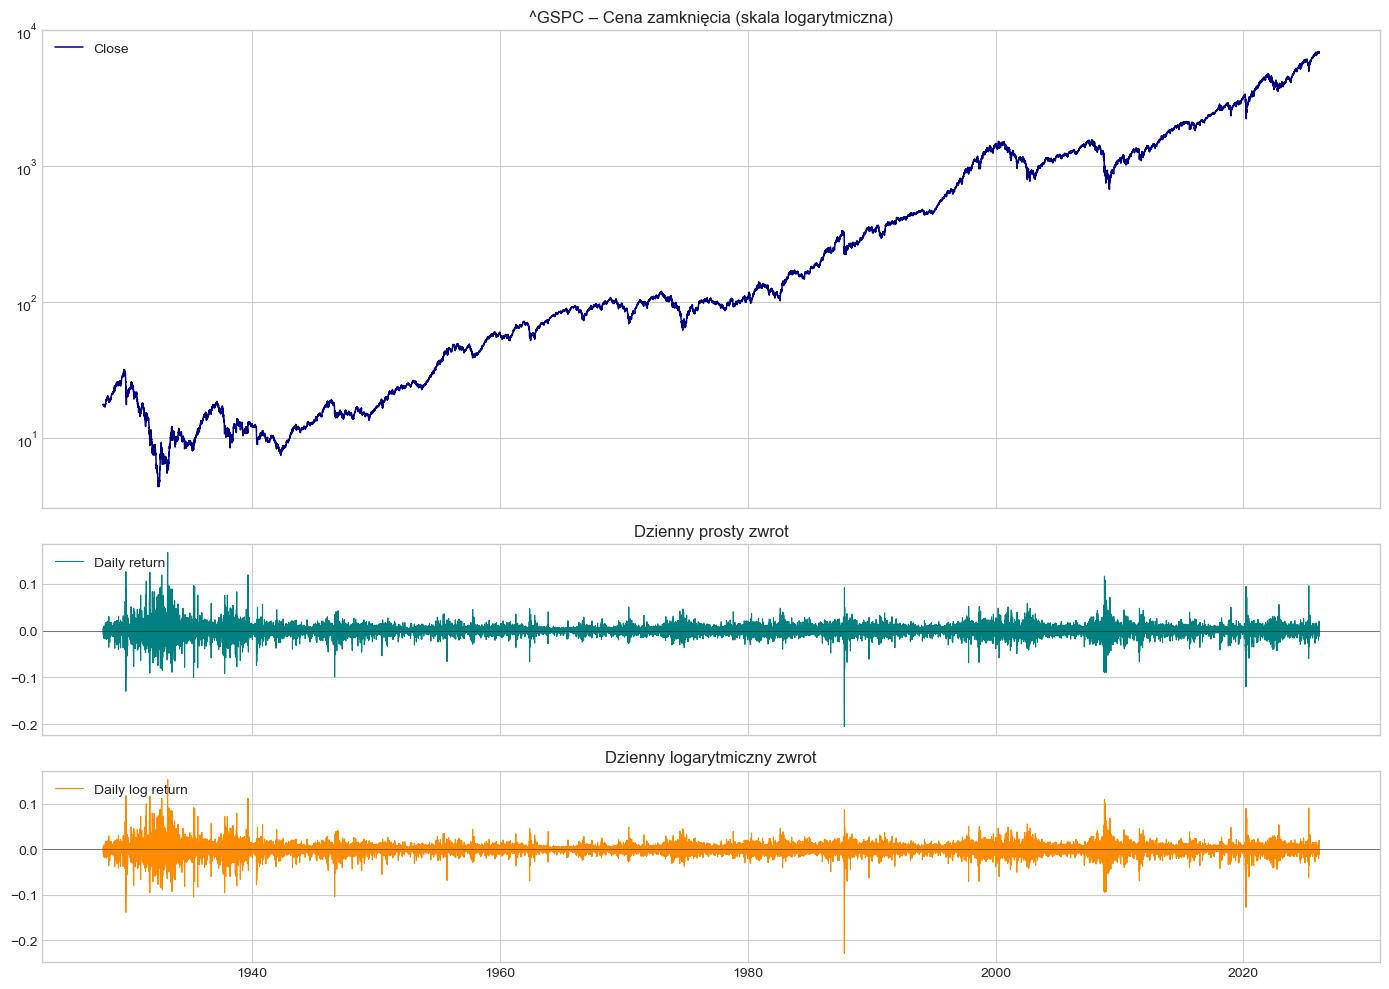

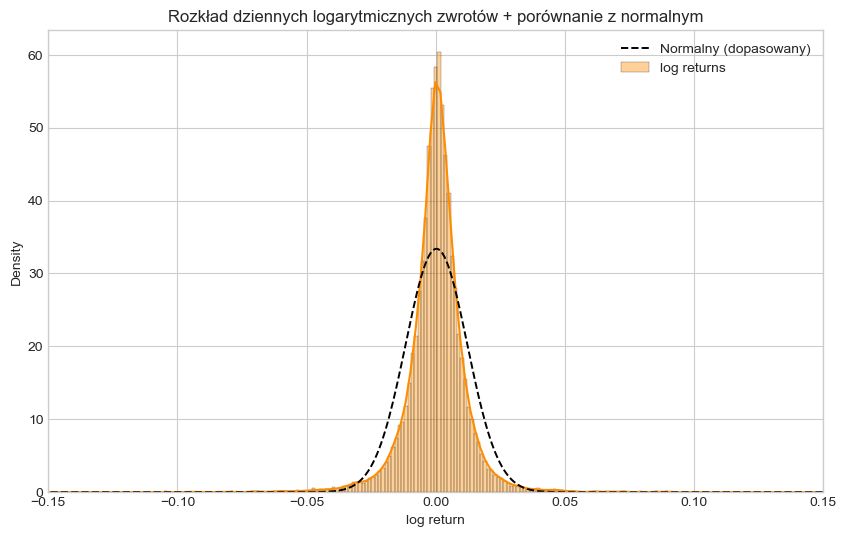

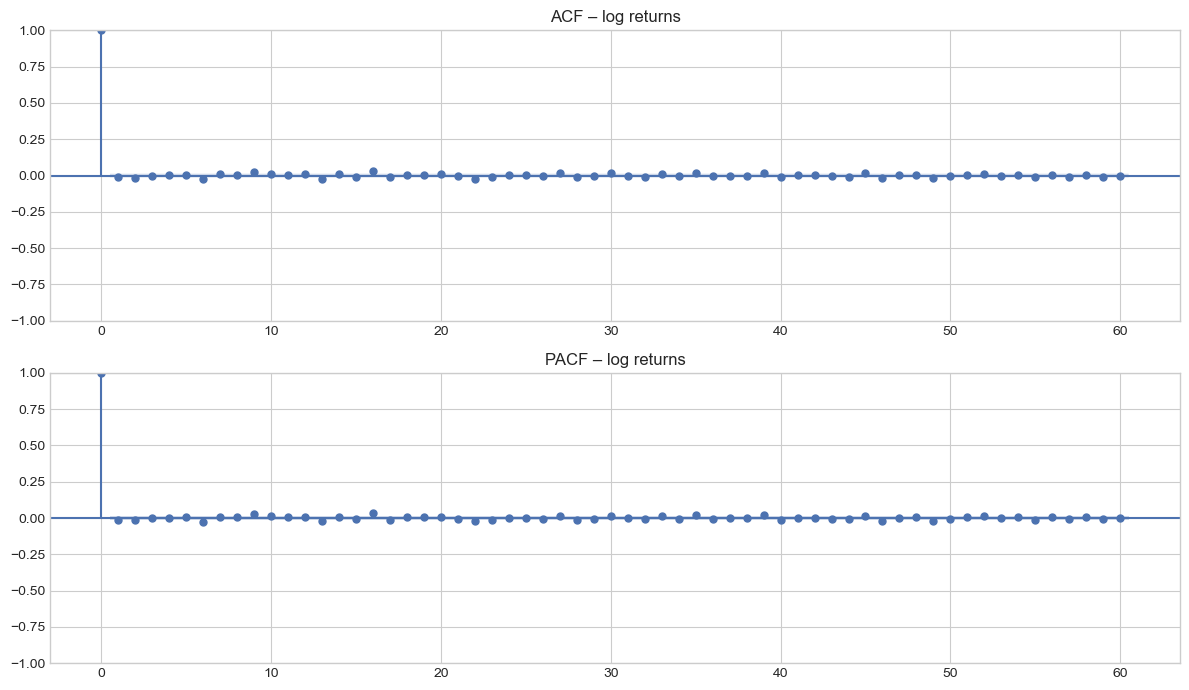

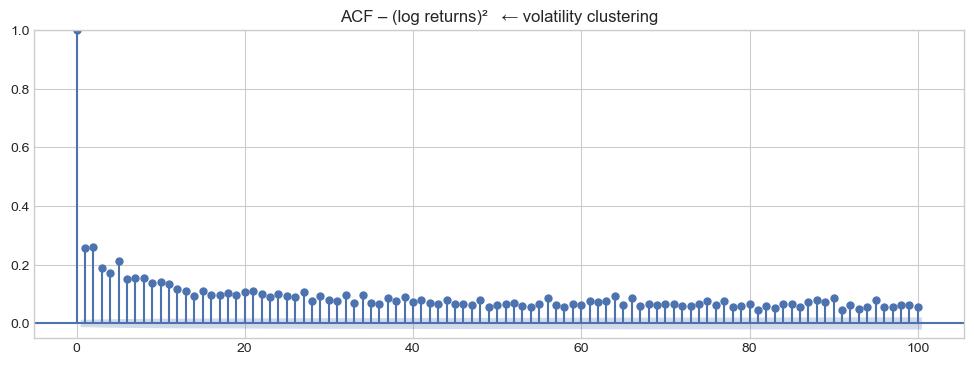


=== 15 największych dziennych spadków ===
Date
1987-10-19   -20.47
1929-10-28   -12.94
2020-03-16   -11.98
1929-10-29   -10.16
1935-04-16    -9.97
1929-11-06    -9.92
1946-09-03    -9.91
2020-03-12    -9.51
1937-10-18    -9.12
1931-10-05    -9.07
2008-10-15    -9.03
2008-12-01    -8.93
1933-07-20    -8.88
2008-09-29    -8.81
1933-07-21    -8.70
Name: return, dtype: float64

=== 15 największych dziennych wzrostów ===
Date
1933-03-15    16.61
1929-10-30    12.53
1931-10-06    12.36
1939-09-05    11.86
1932-09-21    11.81
2008-10-13    11.58
2008-10-28    10.79
1931-06-22    10.51
1935-04-17     9.61
1933-04-20     9.52
2025-04-09     9.52
1935-05-17     9.40
2020-03-24     9.38
2020-03-13     9.29
1932-08-08     9.26
Name: return, dtype: float64
[INFO] adj_close == close w całym zbiorze → pominięto w heatmapie


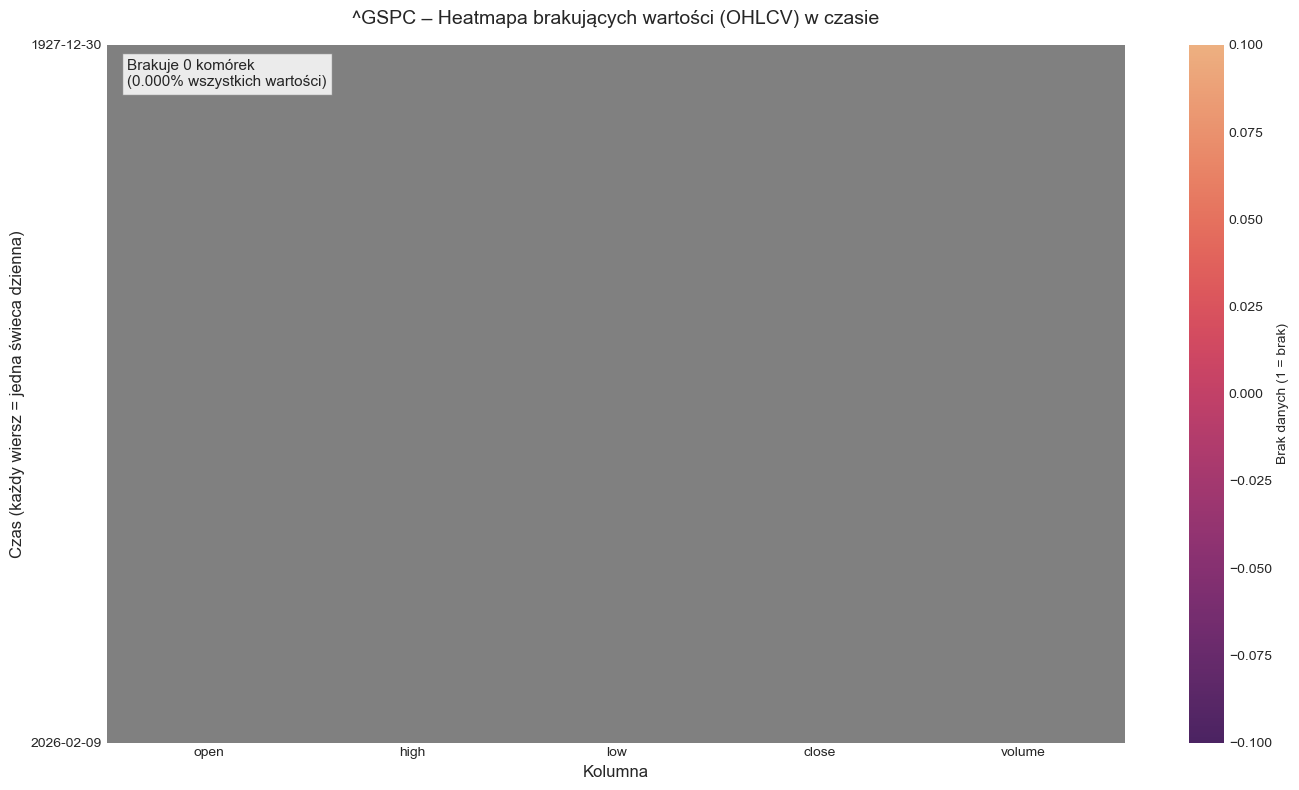


Liczba brakujących wartości w każdej kolumnie:
        Braki (szt.)  % brakujących
open               0            0.0
high               0            0.0
low                0            0.0
close              0            0.0
volume             0            0.0

BRAK BRAKÓW – dane są kompletne w całym zakresie.


In [7]:
# 3. EDA – S&P 500 daily data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("deep")
%matplotlib inline
# %config InlineBackend.figure_format = 'retina'   # jeśli używasz Jupyter

# =============================================================================
# Przygotowanie pomocniczych serii (już na etapie EDA – często robimy to tutaj)
# =============================================================================
df["return"]      = df["close"].pct_change()
df["log_return"]  = np.log(df["close"] / df["close"].shift(1))
df["range"]       = (df["high"] - df["low"]) / df["close"].shift(1)   # daily range %
df["body"]        = (df["close"] - df["open"]) / df["open"]
df["upper_wick"]  = (df["high"] - df[["open","close"]].max(axis=1)) / df["close"]
df["lower_wick"]  = (df[["open","close"]].min(axis=1) - df["low"]) / df["close"]

# =============================================================================
# 3.1 Podstawowe spojrzenie
# =============================================================================
print("\n=== Podstawowe informacje ===")
print(df.index.min().date(), "–", df.index.max().date())
print(f"Liczba rekordów: {len(df):,d}")
print(f"Średni dzienny zwrot: {df['return'].mean():.4%}")
print(f"Średni dzienny |log return|: {df['log_return'].abs().mean():.4%}")
print("\nStatystyki kluczowych kolumn:")
print(df[["open","high","low","close","volume","return","log_return"]].describe(percentiles=[0.01,0.05,0.25,0.5,0.75,0.95,0.99]).round(4))

# =============================================================================
# 3.2 Wizualizacja ceny i zwrotów
# =============================================================================
fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True,
                        gridspec_kw={'height_ratios': [3, 1.2, 1.2]})

# Cena (log scale!)
axs[0].plot(df["close"], color="navy", lw=1.1, label="Close")
axs[0].set_yscale("log")
axs[0].set_title(f"{TICKER} – Cena zamknięcia (skala logarytmiczna)")
axs[0].legend(loc="upper left")

# Zwroty dzienne
axs[1].plot(df["return"], color="teal", lw=0.8, label="Daily return")
axs[1].axhline(0, color="black", lw=0.6, alpha=0.5)
axs[1].set_title("Dzienny prosty zwrot")
axs[1].legend(loc="upper left")

# Logarytmiczne zwroty (częściej używane w modelach)
axs[2].plot(df["log_return"], color="darkorange", lw=0.8, label="Daily log return")
axs[2].axhline(0, color="black", lw=0.6, alpha=0.5)
axs[2].set_title("Dzienny logarytmiczny zwrot")
axs[2].legend(loc="upper left")

plt.tight_layout()
plt.show()

# =============================================================================
# 3.3 Rozkłady – porównanie normalnego + fat tails
# =============================================================================
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(df["log_return"].dropna(), bins=300, kde=True, stat="density",
             color="darkorange", alpha=0.4, label="log returns")

# Dla porównania – normalny rozkład o takiej samej średniej i wariancji
x = np.linspace(df["log_return"].min(), df["log_return"].max(), 500)
normal_pdf = (1 / (df["log_return"].std() * np.sqrt(2*np.pi))) * \
             np.exp( - (x - df["log_return"].mean())**2 / (2 * df["log_return"].std()**2) )
ax.plot(x, normal_pdf, "k--", lw=1.4, label="Normalny (dopasowany)")

ax.set_title("Rozkład dziennych logarytmicznych zwrotów + porównanie z normalnym")
ax.set_xlabel("log return")
ax.set_xlim([-0.15, 0.15])   # zoom na centralną część – ogony widać dalej
ax.legend()
plt.show()

# =============================================================================
# 3.4 Autokorelacja zwrotów i kwadratów zwrotów (klucz do volatility clustering)
# =============================================================================
fig, axs = plt.subplots(2, 1, figsize=(12, 7))

plot_acf(df["log_return"].dropna(), lags=60, ax=axs[0], title="ACF – log returns")
plot_pacf(df["log_return"].dropna(), lags=60, ax=axs[1], title="PACF – log returns", method="ywm")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(df["log_return"].dropna()**2, lags=100, ax=ax,
         title="ACF – (log returns)²   ← volatility clustering")
ax.set_ylim(bottom=-0.05)
plt.show()

# =============================================================================
# 3.5 Największe ruchy w historii (pomaga zrozumieć ekstremalne przypadki)
# =============================================================================
print("\n=== 15 największych dziennych spadków ===")
print(df["return"].nsmallest(15).round(4) * 100)

print("\n=== 15 największych dziennych wzrostów ===")
print(df["return"].nlargest(15).round(4) * 100)

# 3.6 Heatmapa braków w czasie – dla kolumn OHLC(V)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --------------------------------------------------------------------
# Przygotowanie macierzy brakujących wartości (True = brak)
# --------------------------------------------------------------------
missing_matrix = df[["open", "high", "low", "close", "adj_close", "volume"]].isna()

# Jeśli adj_close jest identyczne z close → często yfinance to robi → możemy je pominąć w wizualizacji
if (df["close"] == df["adj_close"]).all():
    missing_matrix = missing_matrix.drop(columns=["adj_close"])
    print("[INFO] adj_close == close w całym zbiorze → pominięto w heatmapie")

# --------------------------------------------------------------------
# Heatmapa – pionowo czas, poziomo kolumny
# --------------------------------------------------------------------
plt.figure(figsize=(14, 8))

# Główna heatmapa
ax = sns.heatmap(
    missing_matrix,
    cmap="flare_r",           # czerwony = brak, jasny = obecne
    cbar_kws={'label': 'Brak danych (1 = brak)'},
    yticklabels=False,        # za dużo wierszy → etykiety y nieczytelne
    xticklabels=True,
    linewidths=0.01,
    linecolor='gray'
)

# Dodatkowe linie pionowe rozdzielające kolumny
ax.vlines(np.arange(0, missing_matrix.shape[1]+1), *ax.get_ylim(), color='gray', lw=0.8)

# Tytuł i podpisy
plt.title(f"{TICKER} – Heatmapa brakujących wartości (OHLCV) w czasie", fontsize=14, pad=15)
plt.xlabel("Kolumna", fontsize=12)
plt.ylabel("Czas (każdy wiersz = jedna świeca dzienna)", fontsize=12)

# Mały trik – pokazujemy zakres dat na osi Y (tylko początek i koniec)
n_rows = len(df)
plt.yticks([0, n_rows-1], [df.index[0].strftime("%Y-%m-%d"), df.index[-1].strftime("%Y-%m-%d")])

# Statystyka w rogu
total_cells = missing_matrix.size
missing_cells = missing_matrix.sum().sum()
missing_pct = missing_cells / total_cells * 100

plt.text(
    0.02, 0.98,
    f"Brakuje {missing_cells:,} komórek\n({missing_pct:.3f}% wszystkich wartości)",
    transform=ax.transAxes,
    fontsize=11,
    va="top",
    ha="left",
    bbox=dict(facecolor="white", alpha=0.85, edgecolor="gray")
)

plt.tight_layout()
plt.show()

# --------------------------------------------------------------------
# Dodatkowe szybkie podsumowanie brakujących po kolumnach
# --------------------------------------------------------------------
print("\nLiczba brakujących wartości w każdej kolumnie:")
missing_counts = missing_matrix.sum()
missing_percent = missing_matrix.mean() * 100
summary = pd.DataFrame({
    "Braki (szt.)": missing_counts,
    "% brakujących": missing_percent.round(4)
}).sort_values("Braki (szt.)", ascending=False)

print(summary)

if missing_counts.sum() == 0:
    print("\nBRAK BRAKÓW – dane są kompletne w całym zakresie.")
elif missing_counts["volume"] > 0 and missing_counts[["open","high","low","close"]].sum().sum() == 0:
    print("\nTylko volume ma braki – typowe dla niektórych źródeł danych.")

In [4]:
# 4. Czyszczenie danych i ponowna walidacja

# brak danych do czyszczenia

In [11]:
# 5. Feature engineering

import numpy as np
import pandas as pd
from pathlib import Path

EPS = 1e-12


def add_log_returns(
    df: pd.DataFrame,
    *,
    close_col: str = "close",
    eps: float = EPS,
    prefix: str = "lr",
) -> pd.DataFrame:
    """
    Dodaje logarytmiczne stopy zwrotu (log-returns) względem poprzedniego zamknięcia.

    log_return(t) = log( (close_t + eps) / (close_{t-1} + eps) )

    Cechy są w pełni przyczynowe – używają wyłącznie przeszłych danych.

    Parameters
    ----------
    df : pd.DataFrame
        Dane wejściowe z kolumną cen zamknięcia
    close_col : str, default="close"
        Nazwa kolumny z ceną zamknięcia
    eps : float, default=1e-12
        Mała wartość zapobiegająca log(0) lub dzieleniu przez zero
    prefix : str, default="lr"
        Przedrostek dla nazwy nowej kolumny

    Returns
    -------
    pd.DataFrame
        Kopia df z dodaną kolumną {prefix}_1
    """
    out = df.copy()
    c = out[close_col].astype(float)
    out[f"{prefix}_1"] = np.log((c + eps) / (c.shift(1) + eps))
    return out


def add_candle_anatomy(
    df: pd.DataFrame,
    *,
    open_col: str = "open",
    high_col: str = "high",
    low_col: str = "low",
    close_col: str = "close",
    eps: float = EPS,
    prefix: str = "candle",
) -> pd.DataFrame:
    """
    Dodaje cechy opisujące anatomię świecy (body, wicki, kierunek) znormalizowane do zakresu świecy.

    Oblicza:
    - body_norm_rng        = |close - open| / (high - low + eps)
    - upper_wick_norm_rng  = (high - max(open,close)) / (high - low + eps)
    - lower_wick_norm_rng  = (min(open,close) - low) / (high - low + eps)
    - direction            = sign(close - open) ∈ {-1, 0, 1}

    Wszystkie cechy są obliczane wyłącznie na podstawie bieżącej świecy → zero leakage.

    Parameters
    ----------
    df : pd.DataFrame
    open_col, high_col, low_col, close_col : str
    eps : float
    prefix : str

    Returns
    -------
    pd.DataFrame
        Kopia df z nowymi kolumnami
    """
    out = df.copy()
    o = out[open_col].astype(float)
    h = out[high_col].astype(float)
    l = out[low_col].astype(float)
    c = out[close_col].astype(float)

    body = (c - o).abs()
    upper_wick = h - np.maximum(o, c)
    lower_wick = np.minimum(o, c) - l
    rng = (h - l).abs()
    denom = rng + eps

    out[f"{prefix}_body_norm_rng"] = body / denom
    out[f"{prefix}_upper_wick_norm_rng"] = upper_wick / denom
    out[f"{prefix}_lower_wick_norm_rng"] = lower_wick / denom
    out[f"{prefix}_direction"] = np.sign(c - o)

    return out


def _true_range(
    high: pd.Series,
    low: pd.Series,
    close: pd.Series,
) -> pd.Series:
    """Pomocnicza funkcja obliczająca True Range (Wilder)."""
    prev_close = close.shift(1)
    tr = pd.concat(
        [
            (high - low).abs(),
            (high - prev_close).abs(),
            (low - prev_close).abs(),
        ],
        axis=1,
    ).max(axis=1)
    return tr


def add_volatility_features(
    df: pd.DataFrame,
    *,
    high_col: str = "high",
    low_col: str = "low",
    close_col: str = "close",
    atr_window: int = 14,
    ret_std_window: int = 20,
    logret_col: str = "lr_1",
    prefix: str = "vol",
) -> pd.DataFrame:
    """
    Dodaje miary zmienności: ATR oraz odchylenie standardowe log-return.

    - ATR (Average True Range) – średnia krocząca True Range
    - ret_std – odchylenie standardowe log-return w oknie

    Obie miary są obliczane na danych przeszłych + bieżących → brak patrzenia w przyszłość.

    Parameters
    ----------
    df : pd.DataFrame
    high_col, low_col, close_col : str
    atr_window : int
    ret_std_window : int
    logret_col : str
        Nazwa kolumny z log-return (musi już istnieć)
    prefix : str

    Returns
    -------
    pd.DataFrame
    """
    out = df.copy()
    h = out[high_col].astype(float)
    l = out[low_col].astype(float)
    c = out[close_col].astype(float)

    tr = _true_range(h, l, c)
    atr = tr.rolling(atr_window, min_periods=atr_window).mean()
    out[f"{prefix}_atr_{atr_window}"] = atr

    if logret_col in out.columns:
        out[f"{prefix}_ret_std_{ret_std_window}"] = out[logret_col].rolling(
            ret_std_window, min_periods=ret_std_window
        ).std()
    else:
        out[f"{prefix}_ret_std_{ret_std_window}"] = np.nan

    return out


def add_volume_features(
    df: pd.DataFrame,
    *,
    volume_col: str = "volume",
    volume_window: int = 50,
    eps: float = EPS,
    prefix: str = "volm",
) -> pd.DataFrame:
    """
    Dodaje relatywny wolumen względem historycznej średniej (bez bieżącego wiersza).

    relative_volume(t) = volume(t) / mean(volume(t-volume_window : t-1) + eps)

    Średnia jest liczona wyłącznie z przeszłości → w pełni przyczynowa cecha.

    Parameters
    ----------
    df : pd.DataFrame
    volume_col : str
    volume_window : int
    eps : float
    prefix : str

    Returns
    -------
    pd.DataFrame
        Kopia df z kolumnami {prefix}_rel oraz {prefix}_log1p_rel
    """
    out = df.copy()
    v = out[volume_col].astype(float)

    # Średnia liczona TYLKO z przeszłości → shift(1) + rolling
    v_mean = v.shift(1).rolling(volume_window, min_periods=volume_window).mean()

    rel_v = v / (v_mean + eps)
    out[f"{prefix}_rel"] = rel_v
    out[f"{prefix}_log1p_rel"] = np.log1p(rel_v.clip(lower=0))

    return out


def add_features_v0_1(
    df: pd.DataFrame,
    *,
    open_col: str = "open",
    high_col: str = "high",
    low_col: str = "low",
    close_col: str = "close",
    volume_col: str = "volume",
    atr_window: int = 14,
    ret_std_window: int = 20,
    volume_window: int = 50,
    output_dir: str = "data/feature_engineering/",
    output_filename: str = "features_v0_1.csv",
) -> pd.DataFrame:
    """
    Główna funkcja agregująca – dodaje zestaw cech w wersji v0.1.

    Kolejność:
    1. log-returns
    2. anatomia świecy
    3. miary zmienności (ATR + std log-return)
    4. relatywny wolumen

    Zwraca kopię DataFrame z nowymi kolumnami i opcjonalnie zapisuje do CSV.

    Wersja v0.1 – podstawowy, przyczynowy zestaw cech do eksperymentów.

    Parameters
    ----------
    df : pd.DataFrame
    open_col, high_col, low_col, close_col, volume_col : str
    atr_window, ret_std_window, volume_window : int
    output_dir : str, default="data/feature_engineering/"
        Katalog do zapisu CSV
    output_filename : str, default="features_v0_1.csv"
        Nazwa pliku CSV

    Returns
    -------
    pd.DataFrame
        DataFrame z cechami
    """
    required = {open_col, high_col, low_col, close_col, volume_col}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Brakuje kolumn w df: {missing}")

    out = df.copy()

    out = add_log_returns(out, close_col=close_col, prefix="lr")
    out = add_candle_anatomy(
        out,
        open_col=open_col,
        high_col=high_col,
        low_col=low_col,
        close_col=close_col,
        prefix="candle",
    )
    out = add_volatility_features(
        out,
        high_col=high_col,
        low_col=low_col,
        close_col=close_col,
        atr_window=atr_window,
        ret_std_window=ret_std_window,
        logret_col="lr_1",
        prefix="vol",
    )
    out = add_volume_features(
        out,
        volume_col=volume_col,
        volume_window=volume_window,
        prefix="volm",
    )

    # Zapisz do CSV, jeśli podano ścieżkę
    output_path = Path(output_dir) / output_filename
    output_path.parent.mkdir(parents=True, exist_ok=True)
    out.to_csv(output_path, index=True)
    print(f"[INFO] Dane z cechami zapisane do: {output_path}")

    return out

In [12]:
# =============================================================================
# Przykład użycia funkcji add_features_v0_1 z zapisem do CSV
# =============================================================================

# Zakładamy, że df już istnieje (wczytany w punkcie 1 lub po czyszczeniu w punkcie 4)
# print(df.head(3))          # możesz odkomentować, żeby zobaczyć surowe dane

print("[INFO] Przed dodaniem cech:")
print("Kształt:", df.shape)
print("Kolumny:", df.columns.tolist())

# -----------------------------------------------------------------------------
# Dodajemy cechy + zapisujemy wynik do CSV
# -----------------------------------------------------------------------------

df_features = add_features_v0_1(
    df=df,
    # parametry domyślne – można zmienić:
    # atr_window=14,
    # ret_std_window=20,
    # volume_window=50,
    
    # Najważniejsze – kontrola zapisu:
    output_dir="data/feature_engineering/",
    output_filename="GSPC_features_v0_1_2026-02-10.csv",   # ← sensowna nazwa z datą
)

# -----------------------------------------------------------------------------
# Krótki podgląd wyniku
# -----------------------------------------------------------------------------

print("\n[INFO] Po dodaniu cech:")
print("Kształt:", df_features.shape)
print("Nowe kolumny:", [col for col in df_features.columns if col not in df.columns])

print("\nPodgląd pierwszych 5 wierszy nowych cech:")
print(df_features.iloc[:5][[
    "lr_1",
    "candle_body_norm_rng",
    "candle_upper_wick_norm_rng",
    "candle_lower_wick_norm_rng",
    "candle_direction",
    "vol_atr_14",
    "vol_ret_std_20",
    "volm_rel",
    "volm_log1p_rel",
]])

# -----------------------------------------------------------------------------
# Sprawdzenie, czy plik naprawdę powstał
# -----------------------------------------------------------------------------

from pathlib import Path

saved_path = Path("data/feature_engineering/GSPC_features_v0_1_2026-02-10.csv")
if saved_path.exists():
    print(f"\n[OK] Plik zapisany pomyślnie: {saved_path}")
    print(f"Rozmiar pliku: {saved_path.stat().st_size / 1024 / 1024:.2f} MB")
else:
    print("\n[WARNING] Plik nie został zapisany – sprawdź uprawnienia do katalogu.")